# 2- groundwater raw uk data importing

This notebook we import the orginal data of the uk's water level from multiple ods files, each file represent a diffrent well. and we returned a merged csv file representing all the wells of the uk.

After that I do some EDA of the data that would not effect the csv file.



---



# Import Libraries

In [ ]:
! pip install odfpy

# Merge Data sets

Merge all of the data sets into one data frame and save it to a csv

you can get the ods data files from : [UK water level data](https://drive.google.com/drive/folders/1zbnotyV49sZDfl9XnCfZDR58yQOgiYmn?usp=sharing)

In [ ]:
import pandas as pd
import glob

# Find all .ods files in the specified directory
ods_files = glob.glob('*.ods')

# Create an empty list to store individual DataFrames
dfs = []

# Read each .ods file into a DataFrame and append to the list
for file in ods_files:
    try:
        df = pd.read_excel(file, engine='odf')
        dfs.append(df)
    except Exception as e:
        print(f"Error reading {file}: {e}")

# Concatenate all DataFrames into a single DataFrame
if dfs:
    merged_df = pd.concat(dfs, ignore_index=True)
    print("Successfully merged all .ods files:")
    display(merged_df.head())
else:
    print("No .ods files found or an error occurred while reading.")

Successfully merged all .ods files:


,ID,Name,Date and Time,Parameter,Value,Unit,Methodology
0,As recorded in the original database.,The name of the data point.,The date and time of the measurement or sampli...,One of the following:• Water depth [from the g...,The numeric value of the measurement.,Unit must be either: • m • ft,Explain the methodology used to collect the da...
1,TF81/2A,Washpit Farm,2023-08-30 00:00:00,Water level elevation a.m.s.l.,44.618,m,NaN
2,TF81/2A,Washpit Farm,2023-08-29 00:00:00,Water level elevation a.m.s.l.,44.6,m,NaN
3,TF81/2A,Washpit Farm,2023-08-28 00:00:00,Water level elevation a.m.s.l.,44.59,m,NaN
4,TF81/2A,Washpit Farm,2023-08-27 00:00:00,Water level elevation a.m.s.l.,44.572,m,NaN


In [ ]:
merged_df.describe()

,ID,Name,Date and Time,Parameter,Value,Unit,Methodology
count,145152,51167,145152,145152,145152.00,145152,27
unique,28,11,42539,2,40870.00,2,1
top,SN00/11,Chilgrove House,The date and time of the measurement or sampli...,Water level elevation a.m.s.l.,1.47,m,Explain the methodology used to collect the da...
freq,10321,8628,27,145125,86.00,145125,27


# Data Prepration

## Find the description rows drop them

In [ ]:
merged_df['Parameter'].unique()

array(['One of the following:• Water depth [from the ground surface]• Water depth [from the top of the well]• Water level elevation a.m.s.l.',
       'Water level elevation a.m.s.l.'], dtype=object)

In [ ]:
description_rows=merged_df[merged_df['Parameter'] =='One of the following:• Water depth [from the ground surface]• Water depth [from the top of the well]• Water level elevation a.m.s.l.']
len(description_rows)

27

In [ ]:
merged_df.drop(description_rows.index,inplace = True)

In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 145125 entries, 1 to 145151
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   ID             145125 non-null  object
 1   Name           51157 non-null   object
 2   Date and Time  145125 non-null  object
 3   Parameter      145125 non-null  object
 4   Value          145125 non-null  object
 5   Unit           145125 non-null  object
 6   Methodology    0 non-null       object
dtypes: object(7)
memory usage: 8.9+ MB


In [ ]:
merged_df.describe()

,ID,Name,Date and Time,Parameter,Value,Unit,Methodology
count,145125,51157,145125,145125,145125.00,145125,0
unique,27,10,42538,1,40869.00,1,0
top,SN00/11,Chilgrove House,2019-10-31 00:00:00 UTC,Water level elevation a.m.s.l.,1.47,m,NaN
freq,10321,8628,16,145125,86.00,145125,NaN


In [ ]:
merged_df.columns

Index(['ID', 'Name ', 'Date and Time', 'Parameter', 'Value', 'Unit',
       'Methodology'],
      dtype='object')

## Drop extra cloumns

In [ ]:
merged_df.drop(columns=['Name ','Parameter','Unit','Methodology'],inplace=True)

## Rename columns

In [ ]:
names={'ID':'well_id','Date and Time':'date','Value':'water_level'}
merged_df.rename(columns=names,inplace=True)

In [ ]:
merged_df.describe()

,well_id,date,water_level
count,145125,145125,145125.00
unique,27,42538,40869.00
top,SN00/11,2019-10-31 00:00:00 UTC,1.47
freq,10321,16,86.00


In [ ]:
merged_df.head()

,well_id,date,water_level
1,TF81/2A,2023-08-30 00:00:00,44.618
2,TF81/2A,2023-08-29 00:00:00,44.6
3,TF81/2A,2023-08-28 00:00:00,44.59
4,TF81/2A,2023-08-27 00:00:00,44.572
5,TF81/2A,2023-08-26 00:00:00,44.554


In [ ]:
merged_df.drop_duplicates(inplace=True)

In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 145125 entries, 1 to 145151
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   well_id      145125 non-null  object
 1   date         145125 non-null  object
 2   water_level  145125 non-null  object
dtypes: object(3)
memory usage: 4.4+ MB


### Change data types

In [ ]:
merged_df['date']=pd.to_datetime(merged_df['date'], format='mixed',utc='Ture')
merged_df['date']=merged_df['date'].dt.tz_convert(None)
merged_df['water_level']=merged_df['water_level'].astype('float')

In [ ]:
merged_df.set_index('date', inplace=True)

In [ ]:
merged_df.sort_index(inplace=True)

In [ ]:
merged_df.head()

,well_id,water_level
date,,
1836-02-29,SU81/1,53.95
1836-03-31,SU81/1,63.40
1836-04-30,SU81/1,63.40
1836-05-31,SU81/1,53.04
1836-06-30,SU81/1,47.24


In [ ]:
merged_df.tail()

,well_id,water_level
date,,
2023-11-07,NO20/14,36.64
2023-11-08,NH95/17,29.60
2023-11-08,NO20/14,36.69
2023-11-09,NH95/17,29.61
2023-11-09,NO20/14,36.71


I can already see some missing data in the begning of the time

### look at the orginal data

**The data is not consestant until 1944 Therfore we need to trim it to start from 1944**

<Axes: xlabel='date'>

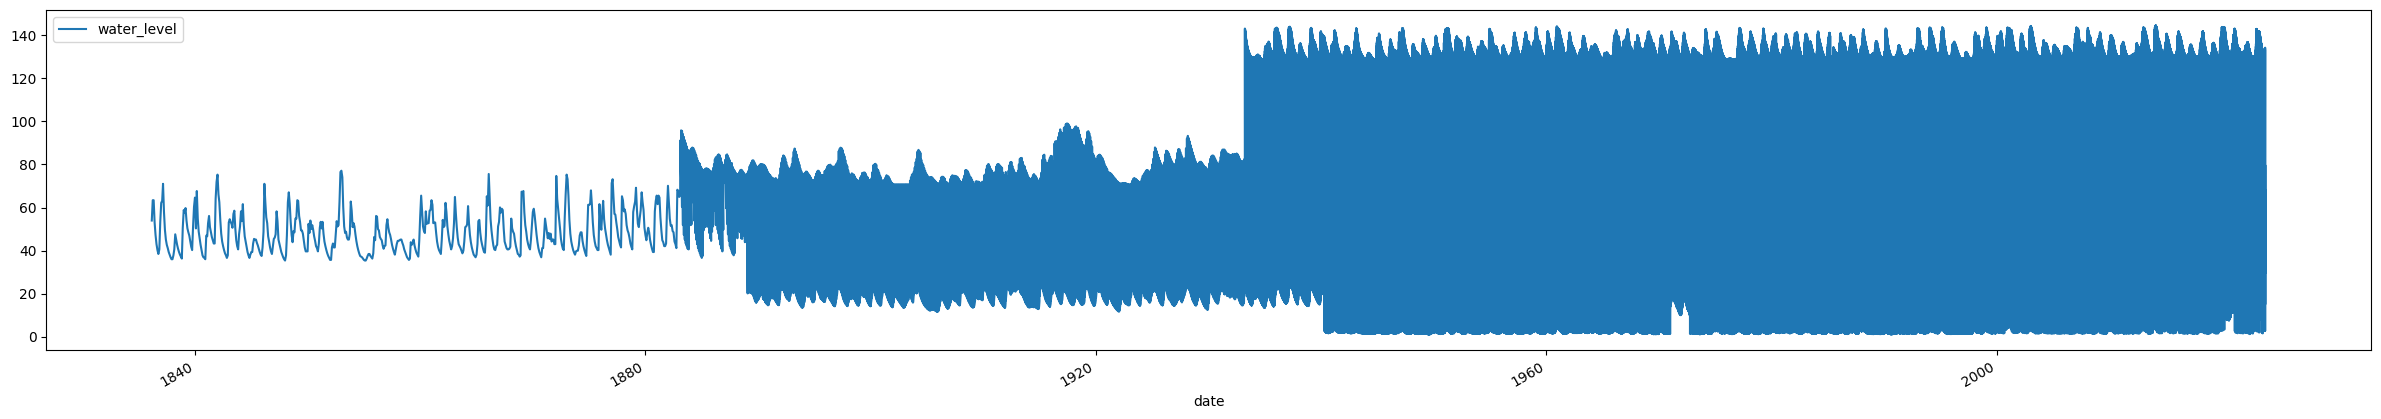

In [ ]:
merged_df.plot(kind='line',figsize=(30,5))

In [ ]:
trimed = merged_df[merged_df.index >= '1944-01-01']
 # if you look late on you will see in the line chart that that the data before 1944 were not as stable as the data after it

In [ ]:
trimed.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 138861 entries, 1944-01-01 00:00:00 to 2023-11-09 00:00:00
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   well_id      138861 non-null  object 
 1   water_level  138861 non-null  float64
dtypes: float64(1), object(1)
memory usage: 3.2+ MB


In [ ]:
trimed.describe()

,water_level
count,138861.000000
mean,63.473163
std,37.749975
min,1.010000
25%,35.269000
50%,64.190000
75%,88.110000
max,144.660000


In [ ]:
trimed.sort_index(inplace=True)

In [ ]:
trimed.head()

,well_id,water_level
date,,
1944-01-01,TL33/4,75.19
1944-01-02,SE94/5,12.62
1944-01-02,SU17/57,129.23
1944-01-03,TV59/7C,1.39
1944-01-09,SE94/5,12.78


<Axes: xlabel='date'>

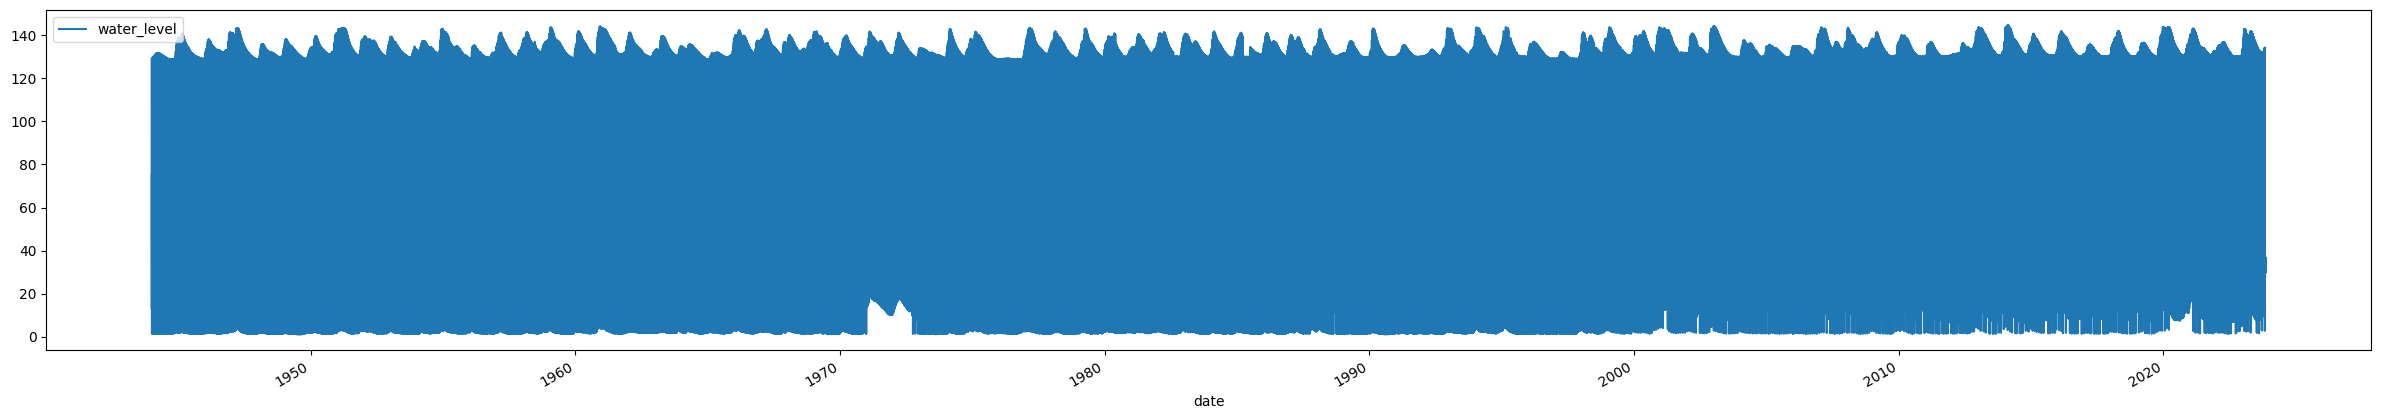

In [ ]:
trimed.plot(kind='line',figsize=(30,5))

In [ ]:
trimed.to_csv('merged_uk_groundwater.csv')

# EDA

### Missing Data

In [ ]:
trimed.isnull().sum()

,0
well_id,0
water_level,0


understanding the number of diffrent wells records each month to detrmin if all wells gave records for all months

In [ ]:
monthly = trimed.copy()


In [ ]:
monthly

,well_id,water_level
date,,
1944-01-01,TL33/4,75.19
1944-01-02,SE94/5,12.62
1944-01-02,SU17/57,129.23
1944-01-03,TV59/7C,1.39
1944-01-09,SE94/5,12.78
...,...,...
2023-11-07,NO20/14,36.64
2023-11-08,NH95/17,29.60
2023-11-08,NO20/14,36.69


In [ ]:
monthly.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 138861 entries, 1944-01-01 00:00:00 to 2023-11-09 00:00:00
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   well_id      138861 non-null  object 
 1   water_level  138861 non-null  float64
dtypes: float64(1), object(1)
memory usage: 3.2+ MB


In [ ]:
monthly.index = monthly.index.to_period('M')
count= monthly.groupby(['date']).aggregate('count')

In [ ]:
count.head()

,well_id,water_level
date,,
1944-01,20,20
1944-02,19,19
1944-03,20,20
1944-04,20,20
1944-05,22,22


<Axes: title={'center': 'Count of number of water well recording in sample 25 months'}, xlabel='date'>

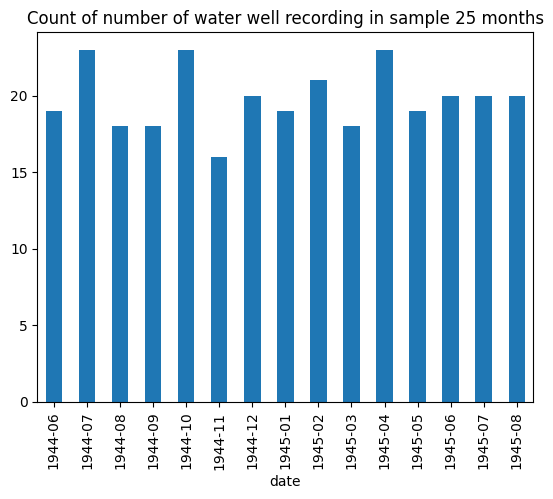

In [ ]:
count['well_id'][5:20].plot(kind='bar',title='Count of number of water well recording in sample 15 months')

**this indicates that some wells does not record every month, therfore we need to merge the data of all the wells for each month to generate one value that represent that month **

## Merge data points for each month using the mean

In [ ]:
monthly.drop(columns='well_id',inplace=True) # we do not need it any more

In [ ]:
monthly.head()

,water_level
date,
1944-01,75.19
1944-01,12.62
1944-01,129.23
1944-01,1.39
1944-01,12.78


In [ ]:
monthly = monthly.groupby(['date']).mean()

In [ ]:
monthly

,water_level
date,
1944-01,52.052000
1944-02,57.104211
1944-03,58.313500
1944-04,57.221500
1944-05,55.016364
...,...
2023-07,60.142778
2023-08,58.829711
2023-09,58.344133


In [ ]:
monthly.describe()

,water_level
count,959.000000
mean,59.341869
std,7.309188
min,32.715634
25%,54.315519
50%,59.318182
75%,64.631006
max,79.045169


In [ ]:
monthly.info()

<class 'pandas.core.frame.DataFrame'>
PeriodIndex: 959 entries, 1944-01 to 2023-11
Freq: M
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   water_level  959 non-null    float64
dtypes: float64(1)
memory usage: 15.0 KB


<Axes: xlabel='date'>

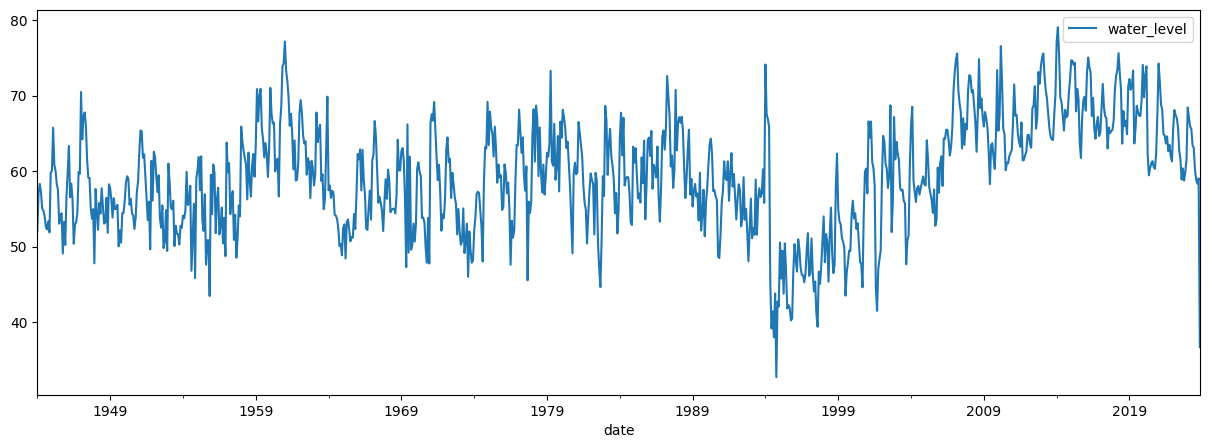

In [ ]:
monthly.plot(kind='line',figsize=(15,5))

This cleaned line chart indicates that the data have some sort of a range and pattern that it moves withen that has been consestant through years. which avoides the error we had in our old data from Jordan